# 미니프로젝트: 앙상블 모델링 (Vibe Coding)

#### <목표>
Day 3에서 배운 **Random Forest, GBM, XGBoost, LightGBM, CatBoost**를 Day 2와 **동일한 제조 데이터셋**에 적용해 봅니다.

- Day 1에서의 EDA, 전처리를 복습해보고
- Day 2에서 배웠던 다중선형회귀·Ridge·Lasso·의사결정나무로 만든 결과와 비교하면서
- Day 3에서 배운 앙상블 모델이 단일 모델 대비 어떤 성능 차이를 보이는지 확인해봅니다.

#### <데이터셋 소개>

**1) 회귀용 — Mining Process Flotation Plant (광물 선광 공정 데이터)**
- 철광석을 선광(flotation)하는 공정에서 1시간 간격으로 수집된 실제 산업 데이터
- 공정 변수로 최종 정광의 불순물(실리카) 비율을 예측

| 변수명 | 설명 |
|:---:|:---|
| date | 측정 일시 |
| % Iron Feed, % Silica Feed | 투입 원광의 철/실리카 품위 |
| Starch Flow, Amina Flow | 전분/아민 투입량 (시약) |
| Ore Pulp Flow, pH, Density | 광액 유량/산도/밀도 |
| Flotation Column 01~07 Air Flow | 플로테이션 컬럼별 공기 유량 |
| Flotation Column 01~07 Level | 플로테이션 컬럼별 액위 |
| % Iron Concentrate | 최종 정광의 철 비율 (실험실 측정) |
| **% Silica Concentrate** | **최종 정광의 실리카(불순물) 비율 — 회귀 타겟** |

**2) 분류용 — Steel Plates Faults (철강 표면 결함 검사 데이터)**
- 철강판 표면을 촬영해 측정한 결함의 위치/크기/광도 등으로 결함 유형을 분류하는 실제 품질검사 데이터

| 변수명 | 설명 |
|:---:|:---|
| X/Y_Minimum, X/Y_Maximum | 결함의 위치 범위 |
| Pixels_Areas, X/Y_Perimeter | 결함의 면적·둘레 |
| Sum/Minimum/Maximum_of_Luminosity | 결함 부위의 광도 |
| Length_of_Conveyer, Steel_Plate_Thickness | 설비/소재 정보 |
| TypeOfSteel_A300, TypeOfSteel_A400 | 철강 타입 |
| Edges_Index, Square_Index, Luminosity_Index 등 | 결함 형태 특징 지수 |
| Pastry, Z_Scratch, K_Scatch, Stains, Dirtiness, Bumps, Other_Faults | 결함 유형 |
| **K_Scatch** | **긴 스크래치성 결함 여부 — 분류 타겟** |

#### <실습 태스크>
| 태스크 | 데이터 파일 | 타겟 변수 | 사용 모델 |
|:---:|:---:|:---:|:---|
| 회귀 | `dataset/day2_miniproject_reg.csv` | `% Silica Concentrate` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (회귀) |
| 분류 | `dataset/day2_miniproject_cls.csv` | `K_Scatch` | Random Forest, GBM, XGBoost, LightGBM, CatBoost (분류) |

#### <진행 순서>
**Part A(회귀)** 를 데이터 불러오기 → 탐색 → 전처리 → 모델링 → 예측 → 고도화 → 결과 해석까지 **끝까지 완료한 뒤**, **Part B(분류)** 를 동일한 흐름으로 진행합니다.

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

**[과제]** 써니는 Day 2에서 사용한 회귀 및 분류 데이터셋에 다양한 트리 기반 앙상블 모델을 적용해 보려고 합니다. 분석 준비와 데이터 전처리뿐만 아니라, 앙상블 모델 구축 및 하이퍼파라미터 탐색에 필요한 라이브러리를 AI와 상의하여 선정하고 불러오는 코드를 작성해 보세요.

In [44]:
import os
import time
import warnings
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, make_scorer,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

warnings.filterwarnings("ignore")

# ===== 한글 폰트 설정 =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None

rcParams["axes.unicode_minus"] = False

# ===== 공통 설정 =====
REG_TARGET = "% Silica Concentrate"
CLS_TARGET = "K_Scatch"
FAULT_COLS = [
    "Pastry", "Z_Scratch", "K_Scatch", "Stains",
    "Dirtiness", "Bumps", "Other_Faults",
]
RANDOM_STATE = 0
TEST_SIZE = 0.3


def set_kr_title(ax, title):
    if KOREAN_FONT:
        ax.set_title(title, fontproperties=KOREAN_FONT)
    else:
        ax.set_title(title)


def get_regscore(true, pred, label=""):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    if label:
        print(f"[{label}]")
    print(f"  RMSE      : {rmse:.4f}")
    print(f"  MAE       : {mae:.4f}")
    print(f"  R-squared : {r2:.4f}")
    return {"RMSE": rmse, "MAE": mae, "R2": r2}


def get_classscore(real, pred, proba=None, label=""):
    metrics = {
        "Accuracy": accuracy_score(real, pred),
        "Precision": precision_score(real, pred, zero_division=0),
        "Recall": recall_score(real, pred, zero_division=0),
        "F1-score": f1_score(real, pred, zero_division=0),
    }
    if proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(real, proba)
    if label:
        print(f"[{label}]")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    print("  혼동행렬:")
    print(confusion_matrix(real, pred))
    return metrics


rmse_scorer = make_scorer(
    lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=True,
)

print("한글 폰트:", KOREAN_FONT.get_name() if KOREAN_FONT else "없음")

한글 폰트: Apple SD Gothic Neo


---
# Part A. 회귀 태스크 — Mining Process Flotation Plant

## A-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_reg.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [45]:
DATA_PATH = os.path.join(os.getcwd(), "dataset", "day2_miniproject_reg.csv")
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (3948, 24)


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-29 12:00:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,2017-03-29 13:00:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,2017-03-29 14:00:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,2017-03-29 15:00:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,2017-03-29 16:00:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


---
## A-1) 데이터 탐색 (EDA)

### A-1-1) Value 기반 탐색

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [46]:
print("=== 기본 정보 ===")
print(df.info())
print("\n=== 결측치 ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "결측치 없음")
print("\n=== 수집 기간 ===")
print(f"{df['date'].min()} ~ {df['date'].max()}")
print(f"관측 수: {len(df):,}건 (1시간 간격)")
print("\n=== 타겟 기술통계 ===")
df[REG_TARGET].describe()

=== 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3948 entries, 0 to 3947
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          3948 non-null   datetime64[ns]
 1   % Iron Feed                   3948 non-null   float64       
 2   % Silica Feed                 3948 non-null   float64       
 3   Starch Flow                   3948 non-null   float64       
 4   Amina Flow                    3948 non-null   float64       
 5   Ore Pulp Flow                 3948 non-null   float64       
 6   Ore Pulp pH                   3948 non-null   float64       
 7   Ore Pulp Density              3948 non-null   float64       
 8   Flotation Column 01 Air Flow  3948 non-null   float64       
 9   Flotation Column 02 Air Flow  3948 non-null   float64       
 10  Flotation Column 03 Air Flow  3948 non-null   float64       
 11  Flotation Column

count    3948.000000
mean        2.322261
std         1.120117
min         0.600000
25%         1.440000
50%         2.000000
75%         2.992500
max         5.530000
Name: % Silica Concentrate, dtype: float64

### A-1-2) Graph 기반 탐색

**[과제]** 써니는 오늘도 어제처럼 시계열 변화 패턴과 변수 간 상관관계를 앙상블 모델링 전에 다시 시각화로 점검하려고 합니다. AI와 함께 시간 흐름에 따른 변수 변화를 시각화해 보세요.

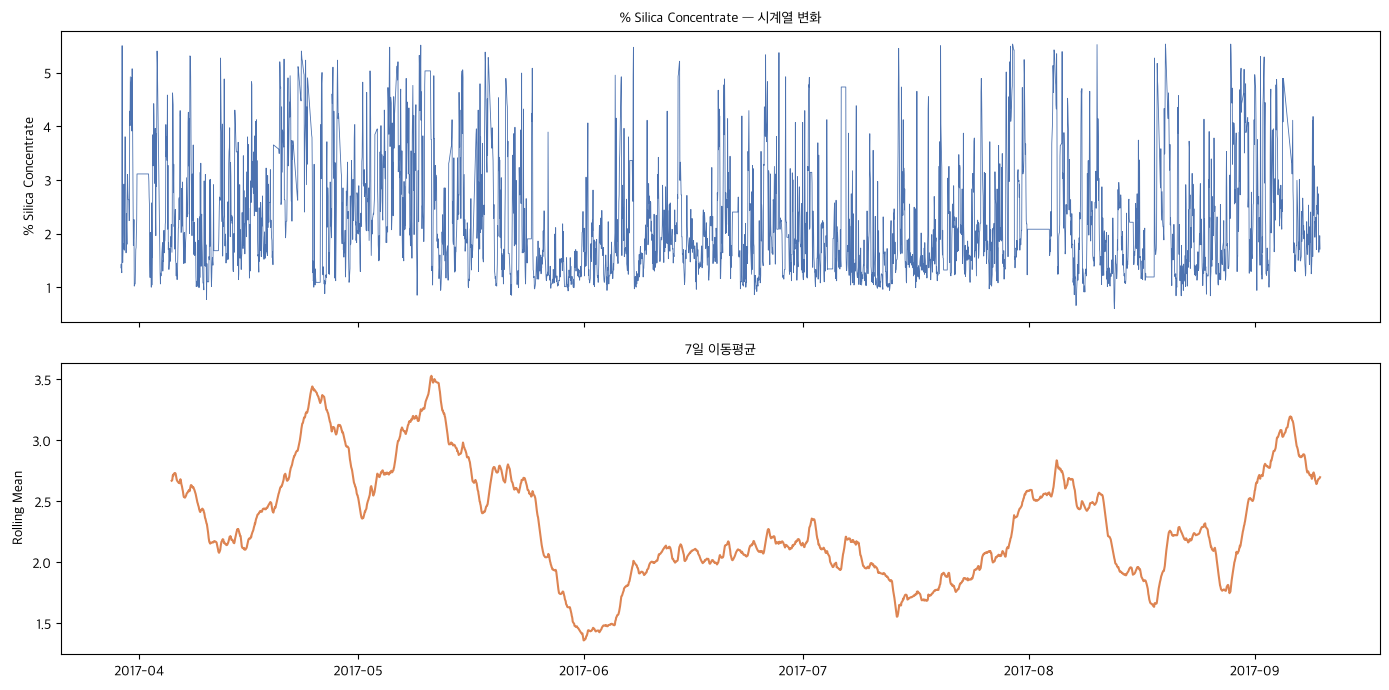

ADF statistic: -7.7225
ADF p-value  : 1.18e-11


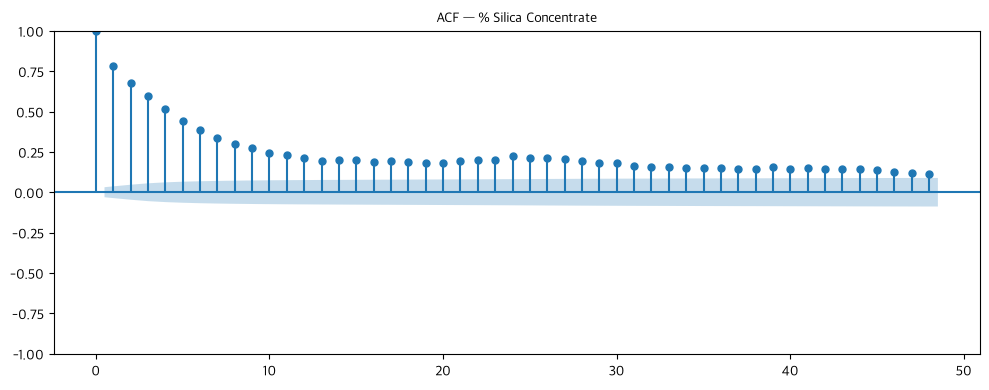

In [47]:
ts = df.set_index("date")[REG_TARGET].sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(ts.index, ts.values, linewidth=0.6, color="#4C72B0")
set_kr_title(axes[0], f"{REG_TARGET} — 시계열 변화")
axes[0].set_ylabel(REG_TARGET)

rolling_mean = ts.rolling(window=24 * 7).mean()
axes[1].plot(ts.index, rolling_mean, color="#DD8452")
set_kr_title(axes[1], "7일 이동평균")
axes[1].set_ylabel("Rolling Mean")
plt.tight_layout()
plt.show()

# 정상성 검정 (ADF)
adf_stat, adf_p, *_ = adfuller(ts.dropna())
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value  : {adf_p:.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(ts.dropna(), lags=48, ax=ax)
set_kr_title(ax, f"ACF — {REG_TARGET}")
plt.tight_layout()
plt.show()

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. AI와 상의해서 상관관계 히트맵을 그려보고 트리 기반 앙상블 모델에서는 이 다중공선성이 Day 2의 선형 모델만큼 문제가 되는지도 함께 생각해 보세요.

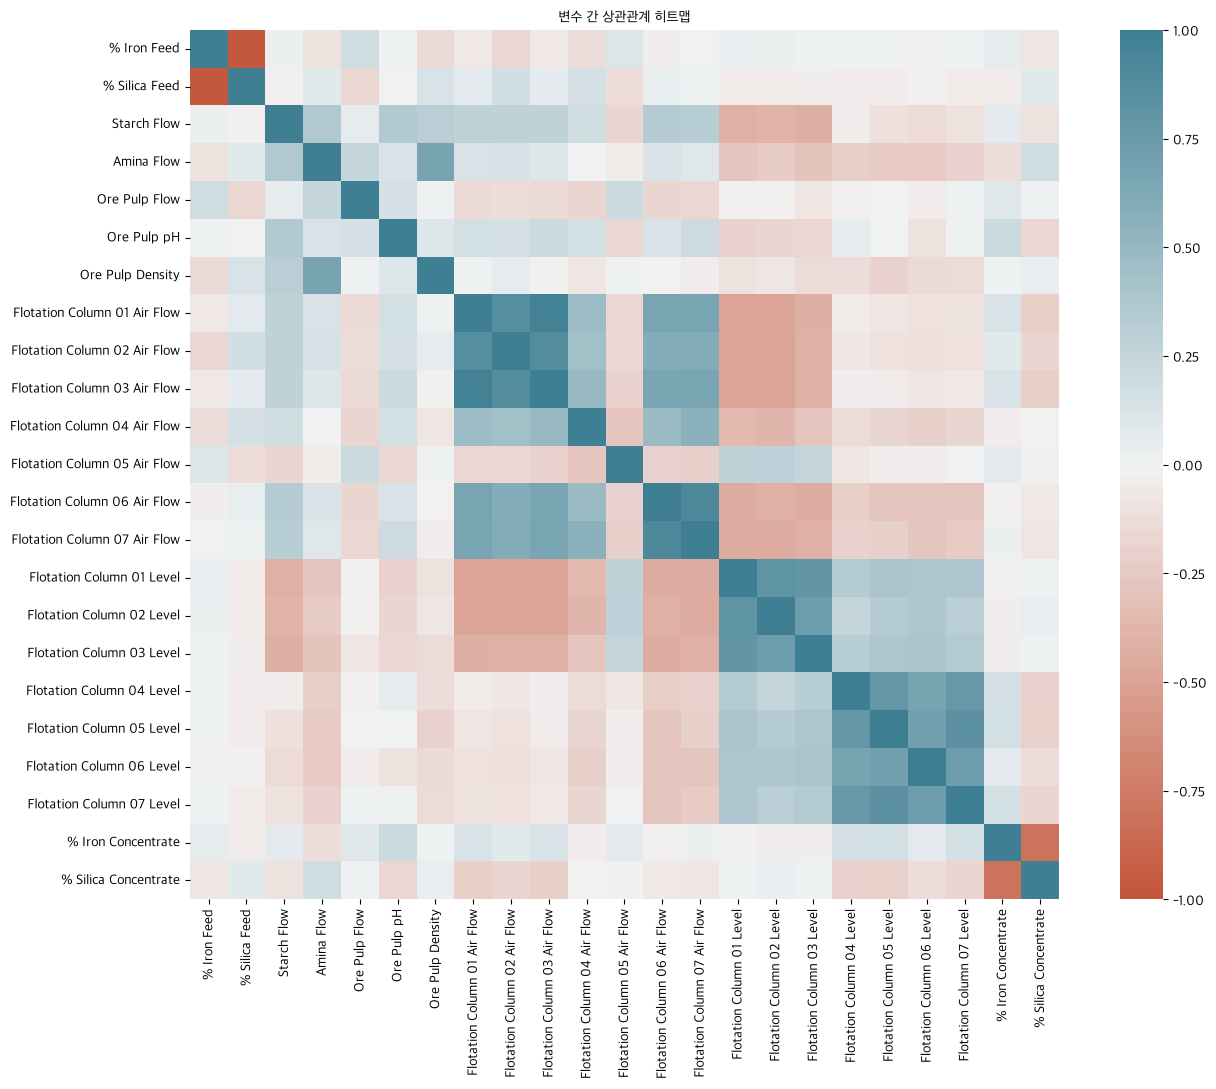

타겟과 상관이 높은 변수 Top 10:
% Silica Concentrate            1.000000
% Iron Concentrate             -0.802749
Flotation Column 01 Air Flow   -0.226252
Flotation Column 03 Air Flow   -0.226228
Flotation Column 05 Level      -0.203567
Flotation Column 04 Level      -0.189860
Flotation Column 07 Level      -0.180455
Amina Flow                      0.180346
Flotation Column 02 Air Flow   -0.174562
Ore Pulp pH                    -0.160985
Name: % Silica Concentrate, dtype: float64

% Iron Concentrate 와 타겟 상관계수: -0.803

[누수(leakage) 검토]
- % Iron Concentrate 는 타겟과 동시에 실험실에서 측정된 정광 품위 → 실시간 예측 시 누수 가능
- 다만 Day 2(Silica.ipynb)에서는 비교를 위해 이 변수를 입력에 포함했으며, 제거 시 R²가 크게 하락
- 본 실습: 누수 여부를 기록하되 Day 2와 동일하게 유지 (A-2-1에서 최종 결정)

[다중공선성]
- 공정 변수(특히 Flotation Column Air Flow/Level) 간 상관이 높음
- 트리/앙상블은 다중공선성에 강함 → 변수 일괄 삭제 불필요
- 선형 모델은 Ridge/Lasso 정규화로 대응 (VIF 기준 일괄 제거는 과도함)


In [48]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr, vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
)
set_kr_title(plt.gca(), "변수 간 상관관계 히트맵")
plt.tight_layout()
plt.show()

target_corr = corr[REG_TARGET].sort_values(key=abs, ascending=False)
print("타겟과 상관이 높은 변수 Top 10:")
print(target_corr.head(10))

iron_corr = corr.loc["% Iron Concentrate", REG_TARGET]
print(f"\n% Iron Concentrate 와 타겟 상관계수: {iron_corr:.3f}")
print("\n[누수(leakage) 검토]")
print("- % Iron Concentrate 는 타겟과 동시에 실험실에서 측정된 정광 품위 → 실시간 예측 시 누수 가능")
print("- 다만 Day 2(Silica.ipynb)에서는 비교를 위해 이 변수를 입력에 포함했으며, 제거 시 R²가 크게 하락")
print("- 본 실습: 누수 여부를 기록하되 Day 2와 동일하게 유지 (A-2-1에서 최종 결정)")
print("\n[다중공선성]")
print("- 공정 변수(특히 Flotation Column Air Flow/Level) 간 상관이 높음")
print("- 트리/앙상블은 다중공선성에 강함 → 변수 일괄 삭제 불필요")
print("- 선형 모델은 Ridge/Lasso 정규화로 대응 (VIF 기준 일괄 제거는 과도함)")

---
## A-2) 데이터 전처리

### A-2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 Heatmap을 통해 타겟변수와 강한 상관관계를 가지는 변수를 발견하였습니다. 해당 변수가 데이터 누수를 유발할 수 있는지가 궁금해졌습니다. AI와 함께 상의하여 해당 변수 제거 여부를 검토하고 결정해보세요.

In [49]:
# A-2-1) 누수 변수 검토 및 결측치 처리
# % Iron Concentrate: 타겟과 동시 측정 → 실무 배포 시 제거 권장
# Day 2(Silica.ipynb)와 동일 비교를 위해 본 실습에서는 유지
LEAKAGE_COLS = []  # 실무용: ["% Iron Concentrate"]
EXCLUDE_COLS = ["date"]

df_reg = df.copy()

if df_reg.isnull().sum().sum() > 0:
    df_reg = df_reg.fillna(df_reg.median(numeric_only=True))
    print("결측치를 중앙값으로 대체했습니다.")
else:
    print("결측치 없음 — 추가 처리 불필요")

feature_cols_reg = [c for c in df_reg.columns if c not in EXCLUDE_COLS + LEAKAGE_COLS + [REG_TARGET]]
print(f"입력 변수 수: {len(feature_cols_reg)}")
print(f"누수 후보(% Iron Concentrate) 포함 여부: {'% Iron Concentrate' in feature_cols_reg}")

# VIF는 참고용으로만 출력 (일괄 제거 시 공정 변수가 거의 사라져 모델이 붕괴함)
X_vif = df_reg[feature_cols_reg]
vif_df = pd.DataFrame({
    "Variable": feature_cols_reg,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

print("\nVIF Top 10 (참고용 — 변수 자동 제거는 하지 않음):")
print(vif_df.head(10).round(2))
print(f"\n※ VIF>20 변수 수: {(vif_df['VIF'] > 20).sum()}개")
print("  → 일괄 제거 시 입력이 1~2개만 남아 R²가 음수가 될 수 있음")
print("  → 다중공선성은 Ridge/Lasso(선형) 및 트리/앙상블 모델이 자체적으로 완화")

df_reg_clean = df_reg[EXCLUDE_COLS + feature_cols_reg + [REG_TARGET]].copy()
df_reg_clean.head()

결측치 없음 — 추가 처리 불필요
입력 변수 수: 22
누수 후보(% Iron Concentrate) 포함 여부: True

VIF Top 10 (참고용 — 변수 자동 제거는 하지 않음):
                        Variable      VIF
10  Flotation Column 04 Air Flow  9933.55
11  Flotation Column 05 Air Flow  8751.08
21            % Iron Concentrate  3939.33
4                  Ore Pulp Flow  3040.74
0                    % Iron Feed  2194.74
9   Flotation Column 03 Air Flow  1577.37
6               Ore Pulp Density  1497.99
7   Flotation Column 01 Air Flow  1248.83
5                    Ore Pulp pH   899.47
13  Flotation Column 07 Air Flow   790.70

※ VIF>20 변수 수: 21개
  → 일괄 제거 시 입력이 1~2개만 남아 R²가 음수가 될 수 있음
  → 다중공선성은 Ridge/Lasso(선형) 및 트리/앙상블 모델이 자체적으로 완화


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-29 12:00:00,60.18,9.34,1060.859297,379.836203,400.982539,9.527187,1.550374,200.035839,195.577700,...,249.992956,753.724247,726.559437,860.557818,477.349197,452.512522,478.219647,470.105547,66.44,1.36
1,2017-03-29 13:00:00,60.18,9.34,2034.926525,322.233975,400.468947,9.700679,1.532017,199.990122,195.106250,...,250.059711,848.675503,777.784437,869.419421,483.816131,469.448172,471.607075,462.665478,66.57,1.43
2,2017-03-29 14:00:00,60.18,9.34,1435.425811,474.656322,399.157083,9.687788,1.645200,200.019311,195.604928,...,250.111328,851.951492,776.293654,879.704989,456.147231,453.227000,447.708467,453.475667,66.64,1.33
3,2017-03-29 15:00:00,60.18,9.34,618.460387,396.377733,398.942522,9.851689,1.559929,199.940833,195.657094,...,250.028506,855.910630,780.369869,882.093896,449.410744,448.581506,450.697578,448.660094,66.41,1.27
4,2017-03-29 16:00:00,59.54,9.56,1367.502858,317.134072,400.836283,9.936163,1.530984,199.878922,196.162864,...,250.122067,851.603513,784.446084,884.840698,450.123050,451.774694,451.574422,449.406894,63.63,5.50


### A-2-2) 입출력 변수 분할 및 데이터 분할

**[과제]** 써니는 `% Silica Concentrate`를 예측하기 위해 입력변수와 타겟 변수를 분리하려고 합니다. Day 2와 마찬가지로 시계열 데이터라는 점을 고려하여 데이터를 분할해보세요.

In [50]:
# 시계열 순서 유지 분할 (앞 70% 학습, 뒤 30% 테스트)
df_reg_clean = df_reg_clean.sort_values("date").reset_index(drop=True)

Y_reg = df_reg_clean[REG_TARGET]
X_reg = df_reg_clean[feature_cols_reg]

split_idx = int(len(df_reg_clean) * (1 - TEST_SIZE))
X_train_reg, X_test_reg = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
Y_train_reg, Y_test_reg = Y_reg.iloc[:split_idx], Y_reg.iloc[split_idx:]

print("입력변수:", X_reg.shape)
print("출력변수:", Y_reg.shape)
print(f"\n시계열 분할 기준 인덱스: {split_idx}")
print("학습:", X_train_reg.shape, "| 기간:", df_reg_clean.loc[:split_idx - 1, "date"].min(),
      "~", df_reg_clean.loc[:split_idx - 1, "date"].max())
print("테스트:", X_test_reg.shape, "| 기간:", df_reg_clean.loc[split_idx:, "date"].min(),
      "~", df_reg_clean.loc[split_idx:, "date"].max())

입력변수: (3948, 22)
출력변수: (3948,)

시계열 분할 기준 인덱스: 2763
학습: (2763, 22) | 기간: 2017-03-29 12:00:00 ~ 2017-07-22 14:00:00
테스트: (1185, 22) | 기간: 2017-07-22 15:00:00 ~ 2017-09-09 23:00:00


### A-2-3) 스케일링 필요 여부 검토

**[과제]** 써니는 Day 2에서는 Ridge/Lasso 모델 특성 때문에 StandardScaler를 적용했었는데 Day 3에서 사용할 Random Forest·GBM·XGBoost·LightGBM·CatBoost도 스케일링이 꼭 필요한지 AI와 상의해서 판단해 보세요.

In [51]:
# 스케일링: 트리 기반 모델(RF/GBM/XGB/LGBM/CatBoost/DT)은 불필요
# 선형 모델(다중선형회귀, Ridge, Lasso)은 StandardScaler 적용
scaler_reg = StandardScaler()
X_train_reg_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_train_reg),
    columns=X_train_reg.columns, index=X_train_reg.index,
)
X_test_reg_scaled = pd.DataFrame(
    scaler_reg.transform(X_test_reg),
    columns=X_test_reg.columns, index=X_test_reg.index,
)

print("[스케일링 판단]")
print("- Random Forest / GBM / XGBoost / LightGBM / CatBoost / 의사결정나무 → 스케일링 불필요 (원본 사용)")
print("- 다중선형회귀 / Ridge / Lasso → StandardScaler 적용 (_scaled 변수 사용)")
print("\n스케일링 후 학습 데이터 요약:")
X_train_reg_scaled.describe().round(2)

[스케일링 판단]
- Random Forest / GBM / XGBoost / LightGBM / CatBoost / 의사결정나무 → 스케일링 불필요 (원본 사용)
- 다중선형회귀 / Ridge / Lasso → StandardScaler 적용 (_scaled 변수 사용)

스케일링 후 학습 데이터 요약:


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate
count,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,...,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00,2763.00
mean,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,...,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.51,-1.49,-2.75,-2.97,-6.59,-3.07,-2.29,-3.21,-3.07,-3.26,...,-3.93,-3.89,-2.69,-2.39,-2.79,-3.46,-2.97,-3.09,-3.36,-2.76
25%,-0.78,-1.13,-0.74,-0.59,-0.24,-0.66,-0.54,-0.84,-0.75,-0.87,...,-1.55,-1.59,-0.66,-0.66,-0.65,-0.93,-1.04,-1.01,-1.00,-0.61
50%,-0.11,-0.02,-0.00,0.18,-0.10,0.02,0.21,0.75,0.84,0.76,...,0.59,0.58,-0.27,-0.27,-0.30,-0.25,-0.34,-0.26,-0.28,0.13
75%,1.29,0.75,0.74,0.73,0.08,0.69,0.71,0.75,0.87,0.76,...,0.59,0.59,0.50,0.52,0.39,0.97,0.98,0.41,0.45,0.76
max,1.37,2.65,3.52,3.02,4.97,3.05,2.09,1.05,1.19,0.79,...,1.20,0.70,2.46,2.27,2.33,3.47,3.48,3.75,3.38,2.62


---
## A-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

Day 2 단일 모델 학습 (RandomizedSearchCV, n_iter=12, cv=3)
[다중선형회귀]
  RMSE      : 0.7044
  MAE       : 0.5406
  R-squared : 0.6144
[Ridge (alpha=233.5721)]
  RMSE      : 0.6757
  MAE       : 0.5186
  R-squared : 0.6452
[Lasso (alpha=0.0379)]
  RMSE      : 0.6653
  MAE       : 0.5144
  R-squared : 0.6561
[의사결정나무 {'min_samples_leaf': 3, 'max_depth': 3}]
  RMSE      : 0.8149
  MAE       : 0.6084
  R-squared : 0.4840

Day 3 앙상블 모델 학습 (RandomizedSearchCV, n_iter=12, cv=3)
[Random Forest {'n_estimators': 300, 'min_samples_leaf': 1, 'max_depth': 5}]
  RMSE      : 0.7270
  MAE       : 0.5717
  R-squared : 0.5893
[GBM {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.01}]
  RMSE      : 0.7387
  MAE       : 0.5980
  R-squared : 0.5760
[XGBoost {'subsample': 1.0, 'reg_lambda': 1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0}]
  RMSE      : 0.7277
  MAE       : 0.5780
  R-squared : 0.5885
[LightGBM {'subsample': 0.8, 'num_leaves':

,Model,Type,RMSE,MAE,R2
0,Lasso,단일,0.6653,0.5144,0.6561
1,Ridge,단일,0.6757,0.5186,0.6452
2,LightGBM,앙상블,0.6785,0.5309,0.6423
3,CatBoost,앙상블,0.6785,0.5251,0.6423
4,다중선형회귀,단일,0.7044,0.5406,0.6144
5,Random Forest,앙상블,0.7270,0.5717,0.5893
6,XGBoost,앙상블,0.7277,0.5780,0.5885
7,GBM,앙상블,0.7387,0.5980,0.5760
8,의사결정나무,단일,0.8149,0.6084,0.4840


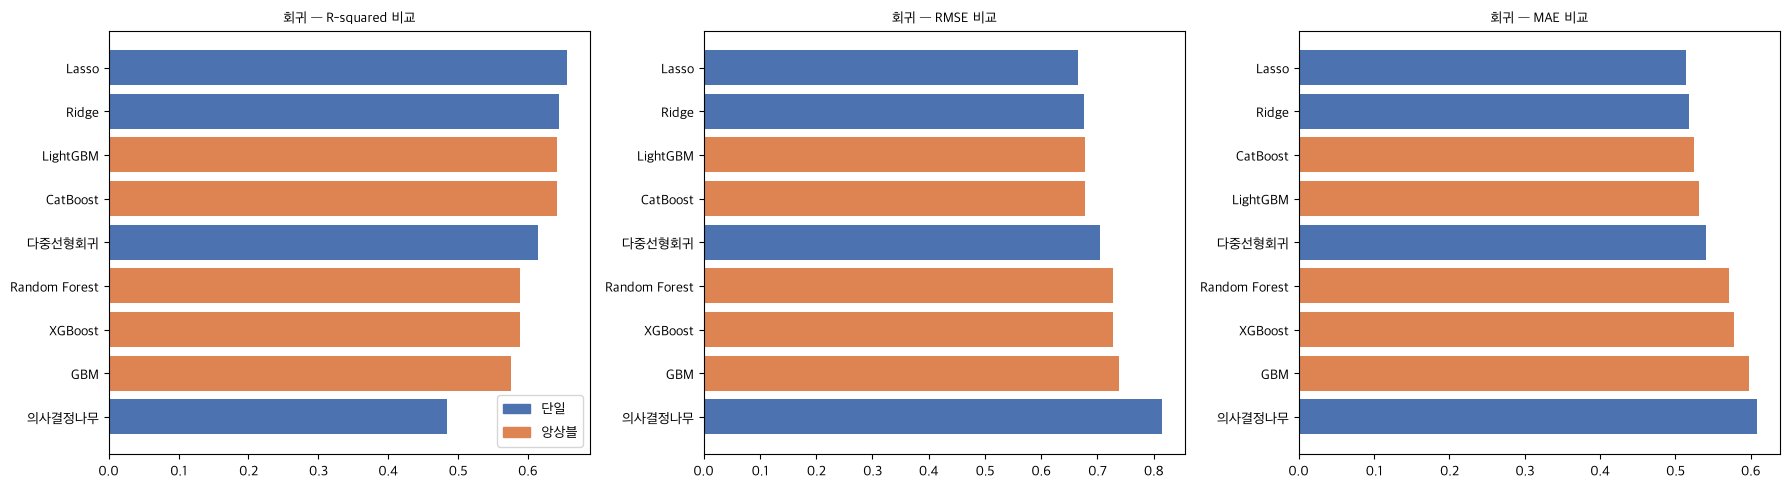


최고 성능 모델: Lasso (R2=0.6561)


In [52]:
# 빠른 튜닝: RandomizedSearchCV (전체 Grid 대신 무작위 n_iter회만 탐색)
N_ITER = 12
TS_CV = TimeSeriesSplit(n_splits=3)

def fast_reg_search(estimator, param_dist, X, y, scoring="r2", n_iter=N_ITER):
    search = RandomizedSearchCV(
        estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=TS_CV,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    search.fit(X, y)
    return search

reg_results = []
reg_models = {}

# ----- Day 2 단일 모델 -----
print("=" * 60)
print(f"Day 2 단일 모델 학습 (RandomizedSearchCV, n_iter={N_ITER}, cv=3)")
print("=" * 60)

# 1) 다중선형회귀
lr = LinearRegression().fit(X_train_reg_scaled, Y_train_reg)
pred = lr.predict(X_test_reg_scaled)
m = get_regscore(Y_test_reg, pred, "다중선형회귀")
reg_results.append({"Model": "다중선형회귀", "Type": "단일", **m})
reg_models["다중선형회귀"] = lr

# 2) Ridge
ridge_search = fast_reg_search(
    Ridge(), {"alpha": np.logspace(-3, 3, 20)}, X_train_reg_scaled, Y_train_reg, scoring=rmse_scorer,
)
ridge = ridge_search.best_estimator_
pred = ridge.predict(X_test_reg_scaled)
m = get_regscore(Y_test_reg, pred, f"Ridge (alpha={ridge_search.best_params_['alpha']:.4f})")
reg_results.append({"Model": "Ridge", "Type": "단일", **m})
reg_models["Ridge"] = ridge

# 3) Lasso
lasso_search = fast_reg_search(
    Lasso(max_iter=5000), {"alpha": np.logspace(-3, 3, 20)}, X_train_reg_scaled, Y_train_reg, scoring=rmse_scorer,
)
lasso = lasso_search.best_estimator_
pred = lasso.predict(X_test_reg_scaled)
m = get_regscore(Y_test_reg, pred, f"Lasso (alpha={lasso_search.best_params_['alpha']:.4f})")
reg_results.append({"Model": "Lasso", "Type": "단일", **m})
reg_models["Lasso"] = lasso

# 4) 의사결정나무
dt_search = fast_reg_search(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    {"max_depth": [3, 5, 7, 10, 15, None], "min_samples_leaf": [1, 3, 5, 10]},
    X_train_reg, Y_train_reg,
)
dt = dt_search.best_estimator_
pred = dt.predict(X_test_reg)
m = get_regscore(Y_test_reg, pred, f"의사결정나무 {dt_search.best_params_}")
reg_results.append({"Model": "의사결정나무", "Type": "단일", **m})
reg_models["의사결정나무"] = dt

# ----- Day 3 앙상블 모델 -----
print("\n" + "=" * 60)
print(f"Day 3 앙상블 모델 학습 (RandomizedSearchCV, n_iter={N_ITER}, cv=3)")
print("=" * 60)

# 5) Random Forest
rf_search = fast_reg_search(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    {"n_estimators": [100, 200, 300], "max_depth": [5, 10, 15, None], "min_samples_leaf": [1, 3, 5]},
    X_train_reg, Y_train_reg,
)
rf = rf_search.best_estimator_
pred = rf.predict(X_test_reg)
m = get_regscore(Y_test_reg, pred, f"Random Forest {rf_search.best_params_}")
reg_results.append({"Model": "Random Forest", "Type": "앙상블", **m})
reg_models["Random Forest"] = rf

# 6) GBM
gbm_search = fast_reg_search(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "min_samples_leaf": [1, 5], "subsample": [0.8, 1.0]},
    X_train_reg, Y_train_reg,
)
gbm = gbm_search.best_estimator_
pred = gbm.predict(X_test_reg)
m = get_regscore(Y_test_reg, pred, f"GBM {gbm_search.best_params_}")
reg_results.append({"Model": "GBM", "Type": "앙상블", **m})
reg_models["GBM"] = gbm

# 7) XGBoost
xgb_search = fast_reg_search(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "gamma": [0, 1, 2], "reg_lambda": [1, 5], "subsample": [0.8, 1.0]},
    X_train_reg, Y_train_reg,
)
xgb = xgb_search.best_estimator_
pred = xgb.predict(X_test_reg)
m = get_regscore(Y_test_reg, pred, f"XGBoost {xgb_search.best_params_}")
reg_results.append({"Model": "XGBoost", "Type": "앙상블", **m})
reg_models["XGBoost"] = xgb

# 8) LightGBM
lgbm_search = fast_reg_search(
    LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "num_leaves": [15, 31], "min_child_samples": [20, 50], "subsample": [0.8, 1.0]},
    X_train_reg, Y_train_reg, n_iter=10,
)
lgbm = lgbm_search.best_estimator_
pred = lgbm.predict(X_test_reg)
m = get_regscore(Y_test_reg, pred, f"LightGBM {lgbm_search.best_params_}")
reg_results.append({"Model": "LightGBM", "Type": "앙상블", **m})
reg_models["LightGBM"] = lgbm

# 9) CatBoost (상대적으로 느려 n_iter 축소)
cat_search = fast_reg_search(
    CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, thread_count=-1),
    {"n_estimators": [100, 200, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "l2_leaf_reg": [1, 3, 5]},
    X_train_reg, Y_train_reg, n_iter=8,
)
cat = cat_search.best_estimator_
pred = cat.predict(X_test_reg)
m = get_regscore(Y_test_reg, pred, f"CatBoost {cat_search.best_params_}")
reg_results.append({"Model": "CatBoost", "Type": "앙상블", **m})
reg_models["CatBoost"] = cat

# ----- 성능 비교표 & 시각화 -----
reg_compare = pd.DataFrame(reg_results).sort_values("R2", ascending=False).reset_index(drop=True)
print("\n=== 회귀 모델 성능 비교 (테스트 세트) ===")
display(reg_compare.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, ["R2", "RMSE", "MAE"], ["R-squared", "RMSE", "MAE"]):
    ascending = metric != "R2"
    plot_df = reg_compare.sort_values(metric, ascending=ascending)
    ax.barh(plot_df["Model"], plot_df[metric],
            color=plot_df["Type"].map({"단일": "#4C72B0", "앙상블": "#DD8452"}))
    set_kr_title(ax, f"회귀 — {title} 비교")
    ax.invert_yaxis()

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color="#4C72B0", label="단일"), Patch(color="#DD8452", label="앙상블")])
plt.tight_layout()
plt.show()

best_reg_model_name = reg_compare.iloc[0]["Model"]
print(f"\n최고 성능 모델: {best_reg_model_name} (R2={reg_compare.iloc[0]['R2']:.4f})")

---
## A-4) 모델 결과 분석 및 고도화

**[과제]** 써니는 Day 2에서 학습한 회귀 모델들과 Day 3에서 학습한 앙상블 모델들이 중요하다고 판단하는 공정 변수가 모델에 따라 얼마나 일관되게 나타나는지 궁금해졌습니다. AI와 함께 변수 중요도 및 회귀 계수를 비교할 수 있는 코드를 작성하고 여러 모델에서 공통적으로 중요하게 선정되는 핵심 공정 변수가 무엇인지 분석해 보세요.

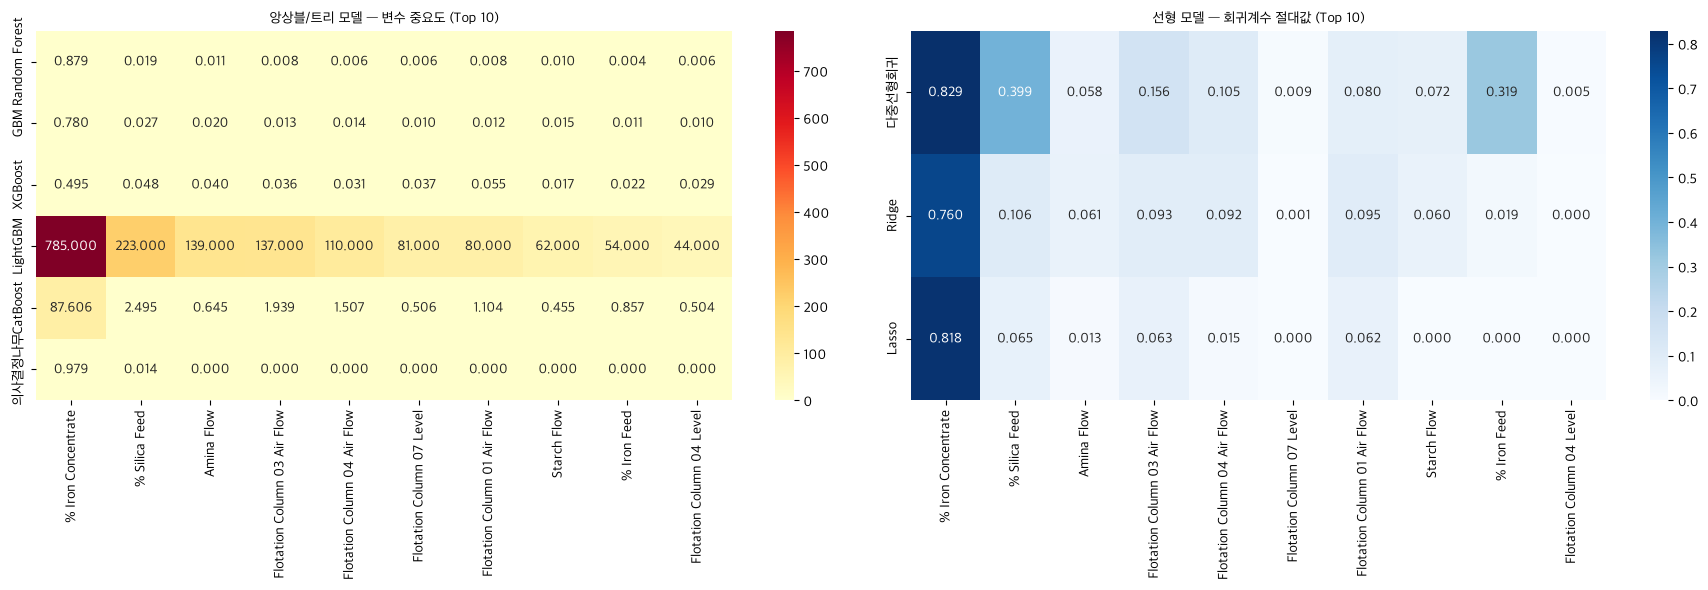

앙상블·선형 모델 공통 핵심 변수:
  - % Iron Concentrate
  - % Iron Feed
  - % Silica Feed
  - Flotation Column 01 Air Flow
  - Flotation Column 03 Air Flow
  - Flotation Column 04 Air Flow
  - Starch Flow


In [53]:
# 변수 중요도 / 회귀계수 비교
importance_models = {
    "Random Forest": rf, "GBM": gbm, "XGBoost": xgb,
    "LightGBM": lgbm, "CatBoost": cat, "의사결정나무": dt,
}
importance_df = pd.DataFrame({
    name: model.feature_importances_
    for name, model in importance_models.items()
}, index=X_train_reg.columns)

# 선형 모델 계수 (절대값 기준)
coef_df = pd.DataFrame({
    "다중선형회귀": np.abs(lr.coef_),
    "Ridge": np.abs(ridge.coef_),
    "Lasso": np.abs(lasso.coef_),
}, index=X_train_reg.columns)

# 상위 10개 변수 — 앙상블 평균 중요도
top_features = importance_df.mean(axis=1).sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

imp_top = importance_df.loc[top_features].T
sns.heatmap(imp_top, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0])
set_kr_title(axes[0], "앙상블/트리 모델 — 변수 중요도 (Top 10)")

coef_top = coef_df.loc[top_features].T
sns.heatmap(coef_top, annot=True, fmt=".3f", cmap="Blues", ax=axes[1])
set_kr_title(axes[1], "선형 모델 — 회귀계수 절대값 (Top 10)")

plt.tight_layout()
plt.show()

# 공통 핵심 변수: 앙상블 중요도 상위 10 ∩ 선형 계수 상위 10
top_ensemble = set(importance_df.mean(axis=1).sort_values(ascending=False).head(10).index)
top_linear = set(coef_df.mean(axis=1).sort_values(ascending=False).head(10).index)
common_features = sorted(top_ensemble & top_linear)

print("앙상블·선형 모델 공통 핵심 변수:")
for f in common_features:
    print(f"  - {f}")
if not common_features:
    print("  (교집합 없음 — 모델별로 중요 변수가 다를 수 있음)")

**[과제]** 써니는 가장 우수했던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 논의하고 GridSearchCV로 최적의 조합을 찾아 성능을 개선해 보세요.

최고 성능 모델 'Lasso' 추가 RandomizedSearchCV 진행...

선형/단순 모델은 A-3에서 이미 최적화 완료

[튜닝 전]
  RMSE      : 0.6653
  MAE       : 0.5144
  R-squared : 0.6561
[튜닝 후]
  RMSE      : 0.6653
  MAE       : 0.5144
  R-squared : 0.6561


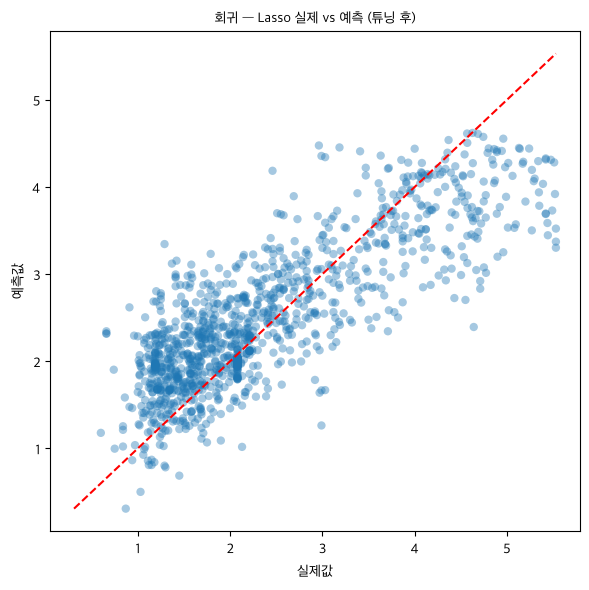

In [54]:
# 최고 성능 모델 추가 미세 튜닝 (빠른 RandomizedSearchCV)
best_reg_model = reg_models[best_reg_model_name]
print(f"최고 성능 모델 '{best_reg_model_name}' 추가 RandomizedSearchCV 진행...\n")

use_scaled = best_reg_model_name in ["Ridge", "Lasso", "다중선형회귀"]
X_fine_train = X_train_reg_scaled if use_scaled else X_train_reg
X_fine_test = X_test_reg_scaled if use_scaled else X_test_reg
tuned_model = best_reg_model

if best_reg_model_name == "Random Forest":
    fine_search = fast_reg_search(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {"n_estimators": [200, 400, 600], "max_depth": [8, 12, 16, None],
         "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", 0.5, 0.8]},
        X_fine_train, Y_train_reg, n_iter=10,
    )
    tuned_model = fine_search.best_estimator_
    print("최적 파라미터:", fine_search.best_params_)
    print(f"CV R2: {fine_search.best_score_:.4f}")

elif best_reg_model_name == "XGBoost":
    fine_search = fast_reg_search(
        XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
        {"n_estimators": [200, 400], "learning_rate": [0.03, 0.05, 0.08],
         "max_depth": [4, 5, 6], "subsample": [0.8, 0.9], "colsample_bytree": [0.7, 0.9]},
        X_fine_train, Y_train_reg, n_iter=10,
    )
    tuned_model = fine_search.best_estimator_
    print("최적 파라미터:", fine_search.best_params_)
    print(f"CV R2: {fine_search.best_score_:.4f}")

elif best_reg_model_name in ["GBM", "LightGBM", "CatBoost"]:
    est_map = {
        "GBM": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
        "CatBoost": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, thread_count=-1),
    }
    fine_search = fast_reg_search(
        est_map[best_reg_model_name],
        {"n_estimators": [200, 400], "learning_rate": [0.03, 0.05, 0.08], "max_depth": [4, 5, 6]},
        X_fine_train, Y_train_reg, n_iter=8,
    )
    tuned_model = fine_search.best_estimator_
    print("최적 파라미터:", fine_search.best_params_)
    print(f"CV R2: {fine_search.best_score_:.4f}")
else:
    print("선형/단순 모델은 A-3에서 이미 최적화 완료")

pred_before = best_reg_model.predict(X_fine_test)
pred_after = tuned_model.predict(X_fine_test)
print("\n[튜닝 전]")
get_regscore(Y_test_reg, pred_before)
print("[튜닝 후]")
get_regscore(Y_test_reg, pred_after)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Y_test_reg, pred_after, alpha=0.4, edgecolors="none")
lims = [min(Y_test_reg.min(), pred_after.min()), max(Y_test_reg.max(), pred_after.max())]
ax.plot(lims, lims, "r--")
ax.set_xlabel("실제값")
ax.set_ylabel("예측값")
set_kr_title(ax, f"회귀 — {best_reg_model_name} 실제 vs 예측 (튜닝 후)")
plt.tight_layout()
plt.show()

---
# Part B. 분류 태스크 — Steel Plates Faults

## B-0) 데이터 불러오기

**[과제]** 써니는 Day 2에서 사용했던 `dataset/day2_miniproject_cls.csv` 파일을 그대로 불러오려고 합니다. 적절한 변수명으로 데이터프레임을 만들어 보세요.

In [55]:
DATA_PATH_CLS = os.path.join(os.getcwd(), "dataset", "day2_miniproject_cls.csv")
SP_Data = pd.read_csv(DATA_PATH_CLS)

print("데이터 크기:", SP_Data.shape)
SP_Data.head()

데이터 크기: (1941, 34)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


---
## B-1) 데이터 탐색 (EDA)

**[과제]** 써니는 오늘도 모델링에 앞서 데이터 상태를 다시 한번 점검하고 싶습니다. AI와 함께 데이터 구조, 결측치, 수집 기간 등 기본적인 특성을 다시 확인해 보세요.

In [56]:
print("=== 기본 정보 ===")
print(SP_Data.info())
print("\n=== 결측치 ===")
missing_cls = SP_Data.isnull().sum()
print(missing_cls[missing_cls > 0] if missing_cls.any() else "결측치 없음")
print("\n=== 타겟 분포 ===")
print(SP_Data[CLS_TARGET].value_counts())
print(f"K_Scatch=1 비율: {SP_Data[CLS_TARGET].mean():.2%}")

=== 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   flo

**[과제]** 써니는 Day 2에서도 확인했던 타겟 변수(K_Scatch)의 클래스 불균형을 앙상블 모델링 전에 다시 한번 점검하려고 합니다. AI와 함께 타겟 변수의 빈도와 비율을 시각화해 보세요.

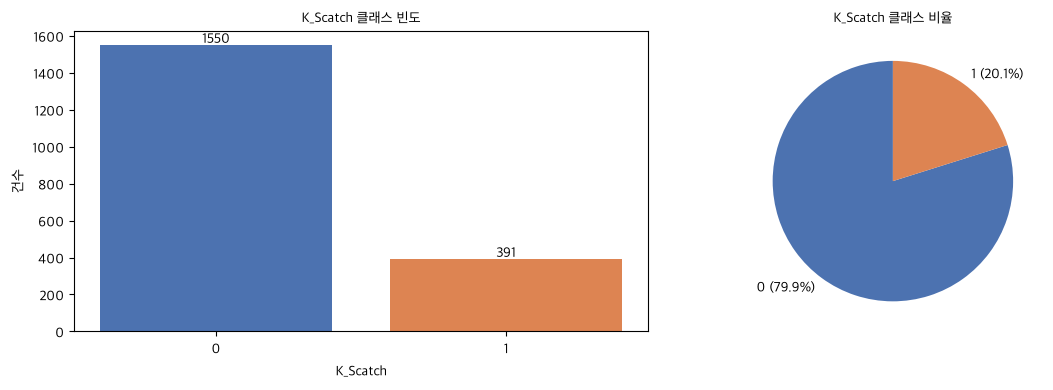

결함 유형별 건수:
Other_Faults    673
Bumps           402
K_Scatch        391
Z_Scratch       190
Pastry          158
Stains           72
Dirtiness        55
dtype: int64


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = SP_Data[CLS_TARGET].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color=["#4C72B0", "#DD8452"])
set_kr_title(axes[0], "K_Scatch 클래스 빈도")
axes[0].set_xlabel("K_Scatch")
axes[0].set_ylabel("건수")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center")

ratio = SP_Data[CLS_TARGET].value_counts(normalize=True).sort_index()
axes[1].pie(ratio.values, labels=[f"{k} ({v:.1%})" for k, v in ratio.items()],
            autopct="", colors=["#4C72B0", "#DD8452"], startangle=90)
set_kr_title(axes[1], "K_Scatch 클래스 비율")

plt.tight_layout()
plt.show()

print("결함 유형별 건수:")
print(SP_Data[FAULT_COLS].sum().sort_values(ascending=False))

---
## B-2) 데이터 전처리

### B-2-1) 타겟 변수 정의

**[과제]** 써니는 K_Scatch를 분류 타겟(0/1)으로 사용하여 모델을 만들려고 합니다. 그런데 다른 결함 유형 변수들이 예측에 어떤 영향을 주는지 궁금해졌습니다. AI와 함께 각 결함 변수와 K_Scatch의 관계를 분석하고, 실제 공정 특성을 학습하기보다 정답을 미리 알려주는 역할을 하는 변수가 있는지 탐색해 보세요. 이후 이러한 변수들을 어떻게 처리하는 것이 적절할지 고민하고 적절한 전처리 방법을 적용해보세요.

In [58]:
# 다른 결함 유형 컬럼은 타겟과 동시에 라벨링된 정보 → 데이터 누수
fault_cross = SP_Data[FAULT_COLS].corr()[CLS_TARGET].drop(CLS_TARGET).sort_values(key=abs, ascending=False)
print("K_Scatch와 결함 유형 변수 상관:")
print(fault_cross)

co_occur = SP_Data.loc[SP_Data[CLS_TARGET] == 1, FAULT_COLS].sum().sort_values(ascending=False)
print("\nK_Scatch=1 행에서 다른 결함 유형 합계:")
print(co_occur)

print("\n[결론] Pastry, Z_Scratch, Stains 등 결함 유형 컬럼은 입력에서 제외 (데이터 누수 방지)")

# 입력(X) / 타겟(Y) 분리
feature_cols_cls = [c for c in SP_Data.columns if c not in FAULT_COLS]
X_cls = SP_Data[feature_cols_cls].copy()
Y_cls = SP_Data[CLS_TARGET].copy()

print(f"\n입력 변수 수: {X_cls.shape[1]}")
print(f"타겟 분포: {Y_cls.value_counts().to_dict()}")
X_cls.head()

K_Scatch와 결함 유형 변수 상관:
Other_Faults   -0.365907
Bumps          -0.256694
Z_Scratch      -0.165446
Pastry         -0.149512
Stains         -0.098579
Dirtiness      -0.085770
Name: K_Scatch, dtype: float64

K_Scatch=1 행에서 다른 결함 유형 합계:
K_Scatch        391
Pastry            0
Z_Scratch         0
Stains            0
Dirtiness         0
Bumps             0
Other_Faults      0
dtype: int64

[결론] Pastry, Z_Scratch, Stains 등 결함 유형 컬럼은 입력에서 제외 (데이터 누수 방지)

입력 변수 수: 27
타겟 분포: {0: 1550, 1: 391}


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000


### B-2-2) 결측치 확인 및 데이터 분할

**[과제]** 써니는 데이터셋에 존재하는 클래스 불균형이 모델 학습과 평가에 영향을 줄 수 있다고 생각했습니다. AI와 함께 타겟 변수의 분포를 확인하고 원본 데이터의 클래스 비율이 학습 데이터와 테스트 데이터에도 유지될 수 있도록 적절한 데이터 분할 방법을 적용해 보세요.

In [59]:
# 결측치 처리
if X_cls.isnull().sum().sum() > 0:
    X_cls = X_cls.fillna(X_cls.median())
    print("결측치를 중앙값으로 대체")
else:
    print("결측치 없음")

# stratify로 클래스 비율 유지
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y_cls,
)

print("전체:", X_cls.shape)
print("학습:", X_train_cls.shape, "| K_Scatch=1 비율:", f"{Y_train_cls.mean():.2%}")
print("테스트:", X_test_cls.shape, "| K_Scatch=1 비율:", f"{Y_test_cls.mean():.2%}")

결측치 없음
전체: (1941, 27)
학습: (1358, 27) | K_Scatch=1 비율: 20.18%
테스트: (583, 27) | K_Scatch=1 비율: 20.07%


### B-2-3) 스케일링/인코딩 필요 여부 검토

**[과제]** 써니는 Day 2에서 로지스틱 회귀 모델 학습을 위해 스케일링을 적용했었습니다. 이번에 사용할 앙상블 모델들도 동일한 전처리가 필요한지 궁금해졌습니다. AI와 함께 모델별 특성을 살펴보고 스케일링과 인코딩이 필요한지 판단하여 적절한 전처리를 적용해 보세요.

In [60]:
# 스케일링: 로지스틱 회귀에만 필요, 트리/앙상블은 원본 사용
# 인코딩: 모든 변수가 수치형 → 추가 인코딩 불필요
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

print("[전처리 판단]")
print("- 로지스틱 회귀 → StandardScaler 적용")
print("- 의사결정나무 / RF / GBM / XGBoost / LightGBM / CatBoost → 스케일링 불필요")
print("- 범주형 변수 없음 → 인코딩 불필요")
print(f"\nTypeOfSteel_A300/A400 포함 여부: {'TypeOfSteel_A300' in X_cls.columns}")

[전처리 판단]
- 로지스틱 회귀 → StandardScaler 적용
- 의사결정나무 / RF / GBM / XGBoost / LightGBM / CatBoost → 스케일링 불필요
- 범주형 변수 없음 → 인코딩 불필요

TypeOfSteel_A300/A400 포함 여부: True


---
## B-3) 모델 학습 및 예측

**[과제]** 써니는 Day 2에서 학습한 회귀 모델과 Day 3에서 학습한 앙상블 모델을 동일한 데이터셋에 적용하여 성능을 비교해 보고자 합니다. AI와 함께 모델 학습, 예측, 성능 평가 코드를 작성하고, 여러 모델의 결과를 한눈에 비교할 수 있는 방법을 찾아 성능을 비교 및 분석해 보세요.

분류 모델 학습 — 기본 설정 (불균형 완화 전)
[로지스틱 회귀 {'C': 10, 'class_weight': None}]
  Accuracy  : 0.9657
  Precision : 0.9369
  Recall    : 0.8889
  F1-score  : 0.9123
  ROC-AUC   : 0.9808
  혼동행렬:
[[459   7]
 [ 13 104]]
[의사결정나무 {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1}]
  Accuracy  : 0.9640
  Precision : 0.9444
  Recall    : 0.8718
  F1-score  : 0.9067
  혼동행렬:
[[460   6]
 [ 15 102]]
[Random Forest {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}]
  Accuracy  : 0.9743
  Precision : 0.9636
  Recall    : 0.9060
  F1-score  : 0.9339
  ROC-AUC   : 0.9928
  혼동행렬:
[[462   4]
 [ 11 106]]
[GBM {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.8}]
  Accuracy  : 0.9743
  Precision : 0.9636
  Recall    : 0.9060
  F1-score  : 0.9339
  혼동행렬:
[[462   4]
 [ 11 106]]
[XGBoost {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}]
  Accuracy  : 0.9794
  Precision : 0.9646
  Recall    : 0.9316
 

,Model,Type,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,앙상블,0.9794,0.9646,0.9316,0.9478,0.9949
1,LightGBM,앙상블,0.9760,0.9640,0.9145,0.9386,0.9949
2,Random Forest,앙상블,0.9743,0.9636,0.9060,0.9339,0.9928
3,GBM,앙상블,0.9743,0.9636,0.9060,0.9339,NaN
4,CatBoost,앙상블,0.9743,0.9636,0.9060,0.9339,0.9938
5,로지스틱 회귀,단일,0.9657,0.9369,0.8889,0.9123,0.9808
6,의사결정나무,단일,0.9640,0.9444,0.8718,0.9067,NaN


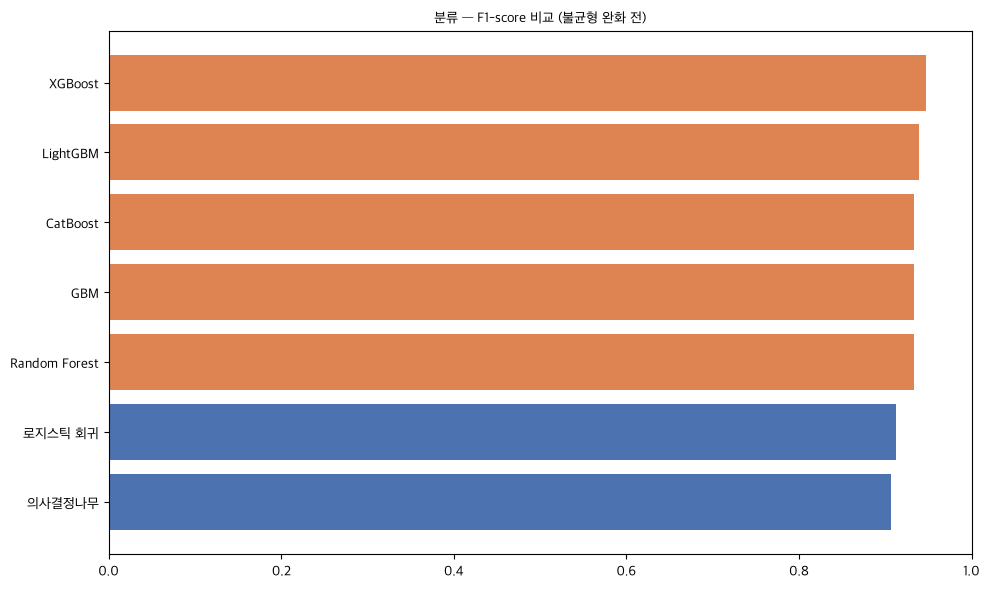

In [61]:
cls_results = []
cls_models = {}
scale_pos_weight = (Y_train_cls == 0).sum() / (Y_train_cls == 1).sum()

print("=" * 60)
print("분류 모델 학습 — 기본 설정 (불균형 완화 전)")
print("=" * 60)

# Day 2 단일 모델
lr_cls_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    {"C": [0.01, 0.1, 1, 10], "class_weight": [None, "balanced"]},
    scoring="f1", cv=5, n_jobs=-1,
)
lr_cls_grid.fit(X_train_cls_scaled, Y_train_cls)
lr_cls = lr_cls_grid.best_estimator_
lr_pred = lr_cls.predict(X_test_cls_scaled)
lr_proba = lr_cls.predict_proba(X_test_cls_scaled)[:, 1]
m = get_classscore(Y_test_cls, lr_pred, lr_proba, f"로지스틱 회귀 {lr_cls_grid.best_params_}")
cls_results.append({"Model": "로지스틱 회귀", "Type": "단일", **m})
cls_models["로지스틱 회귀"] = lr_cls

dt_cls_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"max_depth": [3, 5, 7, 10, None], "min_samples_leaf": [1, 3, 5], "class_weight": [None, "balanced"]},
    scoring="f1", cv=5, n_jobs=-1,
)
dt_cls_grid.fit(X_train_cls, Y_train_cls)
dt_cls = dt_cls_grid.best_estimator_
dt_pred = dt_cls.predict(X_test_cls)
m = get_classscore(Y_test_cls, dt_pred, label=f"의사결정나무 {dt_cls_grid.best_params_}")
cls_results.append({"Model": "의사결정나무", "Type": "단일", **m})
cls_models["의사결정나무"] = dt_cls

# Day 3 앙상블 (기본)
rf_cls_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {"n_estimators": [100, 300], "max_depth": [5, 10, None], "min_samples_leaf": [1, 3, 5]},
    scoring="f1", cv=3, n_jobs=-1,
)
rf_cls_grid.fit(X_train_cls, Y_train_cls)
rf_cls = rf_cls_grid.best_estimator_
m = get_classscore(Y_test_cls, rf_cls.predict(X_test_cls), rf_cls.predict_proba(X_test_cls)[:, 1],
                   f"Random Forest {rf_cls_grid.best_params_}")
cls_results.append({"Model": "Random Forest", "Type": "앙상블", **m})
cls_models["Random Forest"] = rf_cls

gbm_cls_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    {"n_estimators": [100, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "min_samples_leaf": [1, 5], "subsample": [0.8, 1.0]},
    scoring="f1", cv=3, n_jobs=-1,
)
gbm_cls_grid.fit(X_train_cls, Y_train_cls)
gbm_cls = gbm_cls_grid.best_estimator_
m = get_classscore(Y_test_cls, gbm_cls.predict(X_test_cls), label=f"GBM {gbm_cls_grid.best_params_}")
cls_results.append({"Model": "GBM", "Type": "앙상블", **m})
cls_models["GBM"] = gbm_cls

xgb_cls_grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0),
    {"n_estimators": [100, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "gamma": [0, 2], "subsample": [0.8, 1.0]},
    scoring="f1", cv=3, n_jobs=-1,
)
xgb_cls_grid.fit(X_train_cls, Y_train_cls)
xgb_cls = xgb_cls_grid.best_estimator_
m = get_classscore(Y_test_cls, xgb_cls.predict(X_test_cls), xgb_cls.predict_proba(X_test_cls)[:, 1],
                   f"XGBoost {xgb_cls_grid.best_params_}")
cls_results.append({"Model": "XGBoost", "Type": "앙상블", **m})
cls_models["XGBoost"] = xgb_cls

lgbm_cls_grid = GridSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    {"n_estimators": [100, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "num_leaves": [15, 31], "min_child_samples": [20, 50]},
    scoring="f1", cv=3, n_jobs=-1,
)
lgbm_cls_grid.fit(X_train_cls, Y_train_cls)
lgbm_cls = lgbm_cls_grid.best_estimator_
m = get_classscore(Y_test_cls, lgbm_cls.predict(X_test_cls), lgbm_cls.predict_proba(X_test_cls)[:, 1],
                   f"LightGBM {lgbm_cls_grid.best_params_}")
cls_results.append({"Model": "LightGBM", "Type": "앙상블", **m})
cls_models["LightGBM"] = lgbm_cls

cat_cls_grid = GridSearchCV(
    CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    {"n_estimators": [100, 300], "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 5], "l2_leaf_reg": [1, 3, 5]},
    scoring="f1", cv=3, n_jobs=-1,
)
cat_cls_grid.fit(X_train_cls, Y_train_cls)
cat_cls = cat_cls_grid.best_estimator_
m = get_classscore(Y_test_cls, cat_cls.predict(X_test_cls), cat_cls.predict_proba(X_test_cls)[:, 1],
                   f"CatBoost {cat_cls_grid.best_params_}")
cls_results.append({"Model": "CatBoost", "Type": "앙상블", **m})
cls_models["CatBoost"] = cat_cls

# 성능 비교
cls_compare = pd.DataFrame(cls_results).sort_values("F1-score", ascending=False).reset_index(drop=True)
print("\n=== 분류 모델 성능 비교 (기본, 테스트 세트) ===")
display(cls_compare.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = cls_compare.sort_values("F1-score", ascending=True)
ax.barh(plot_df["Model"], plot_df["F1-score"],
        color=plot_df["Type"].map({"단일": "#4C72B0", "앙상블": "#DD8452"}))
set_kr_title(ax, "분류 — F1-score 비교 (불균형 완화 전)")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

---
## B-5) 모델 결과 분석 및 고도화

**[과제]** 써니는 클래스 불균형이 성능에 영향을 줄 수 있다고 생각했습니다. 다만 모델마다 불균형을 다루는 방식이 다르다는 것을 알게 되었습니다. AI와 함께 각 모델에 맞는 불균형 완화 방법을 적용하고 적용 전후 성능을 비교해 보세요.

> 예:Random Forest는 `class_weight`, GBM은 `sample_weight`, XGBoost는 `scale_pos_weight`, LightGBM은 `is_unbalance`, CatBoost는 `auto_class_weights`

앙상블 5종 — 불균형 완화 적용 전후 비교


,Model,F1 (before),F1 (after),F1 변화,Recall (before),Recall (after)
2,XGBoost,0.9478,0.9478,0.0000,0.9316,0.9316
4,CatBoost,0.9339,0.9478,0.0139,0.9060,0.9316
3,LightGBM,0.9386,0.9437,0.0051,0.9145,0.9316
0,Random Forest,0.9339,0.9339,0.0000,0.9060,0.9060
1,GBM,0.9339,0.9339,0.0000,0.9060,0.9060


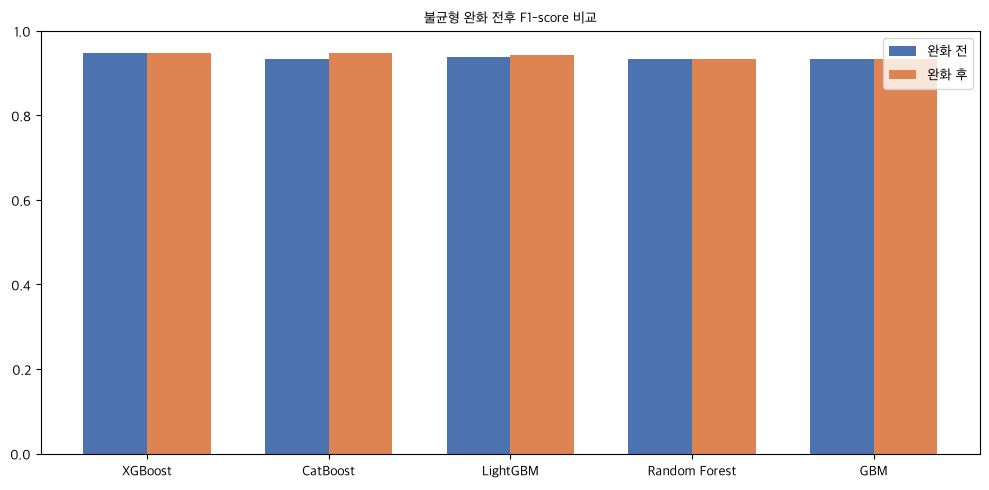


불균형 완화 후 최고 F1 모델: XGBoost (F1=0.9478)


In [62]:
# 모델별 불균형 완화 방법 적용 후 재학습
print("=" * 60)
print("앙상블 5종 — 불균형 완화 적용 전후 비교")
print("=" * 60)

sample_weights = np.where(Y_train_cls == 1,
                          (Y_train_cls == 0).sum() / (Y_train_cls == 1).sum(), 1.0)

imbalance_models = {}

# Random Forest — class_weight='balanced'
rf_bal = RandomForestClassifier(
    random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1,
    **rf_cls_grid.best_params_,
)
rf_bal.fit(X_train_cls, Y_train_cls)
imbalance_models["Random Forest"] = rf_bal

# GBM — sample_weight
gbm_bal = GradientBoostingClassifier(**gbm_cls_grid.best_params_, random_state=RANDOM_STATE)
gbm_bal.fit(X_train_cls, Y_train_cls, sample_weight=sample_weights)
imbalance_models["GBM"] = gbm_bal

# XGBoost — scale_pos_weight
xgb_bal = XGBClassifier(**xgb_cls_grid.best_params_, random_state=RANDOM_STATE,
                        scale_pos_weight=scale_pos_weight, eval_metric="logloss", verbosity=0)
xgb_bal.fit(X_train_cls, Y_train_cls)
imbalance_models["XGBoost"] = xgb_bal

# LightGBM — is_unbalance
lgbm_bal = LGBMClassifier(**lgbm_cls_grid.best_params_, random_state=RANDOM_STATE,
                          is_unbalance=True, verbose=-1)
lgbm_bal.fit(X_train_cls, Y_train_cls)
imbalance_models["LightGBM"] = lgbm_bal

# CatBoost — auto_class_weights
cat_bal = CatBoostClassifier(**cat_cls_grid.best_params_, random_state=RANDOM_STATE,
                             auto_class_weights="Balanced", verbose=0)
cat_bal.fit(X_train_cls, Y_train_cls)
imbalance_models["CatBoost"] = cat_bal

# 전후 비교표
imb_compare_rows = []
for name in ["Random Forest", "GBM", "XGBoost", "LightGBM", "CatBoost"]:
    before = cls_models[name]
    after = imbalance_models[name]
    pred_b = before.predict(X_test_cls)
    pred_a = after.predict(X_test_cls)
    f1_b = f1_score(Y_test_cls, pred_b)
    f1_a = f1_score(Y_test_cls, pred_a)
    imb_compare_rows.append({
        "Model": name,
        "F1 (before)": f1_b,
        "F1 (after)": f1_a,
        "F1 변화": f1_a - f1_b,
        "Recall (before)": recall_score(Y_test_cls, pred_b),
        "Recall (after)": recall_score(Y_test_cls, pred_a),
    })

imb_compare = pd.DataFrame(imb_compare_rows).sort_values("F1 (after)", ascending=False)
display(imb_compare.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(imb_compare))
w = 0.35
ax.bar(x - w/2, imb_compare["F1 (before)"], w, label="완화 전", color="#4C72B0")
ax.bar(x + w/2, imb_compare["F1 (after)"], w, label="완화 후", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(imb_compare["Model"])
ax.set_ylim(0, 1)
set_kr_title(ax, "불균형 완화 전후 F1-score 비교")
ax.legend()
plt.tight_layout()
plt.show()

cls_models_balanced = imbalance_models
best_cls_name = imb_compare.iloc[0]["Model"]
print(f"\n불균형 완화 후 최고 F1 모델: {best_cls_name} (F1={imb_compare.iloc[0]['F1 (after)']:.4f})")

**[과제]** 써니는 불균형 완화까지 적용한 5개 모델의 변수 중요도를 비교해서, K_Scatch 결함 여부에 공통적으로 큰 영향을 주는 변수가 무엇인지 확인하려고 합니다. AI와 상의해서 비교 시각화를 만들어 보세요.

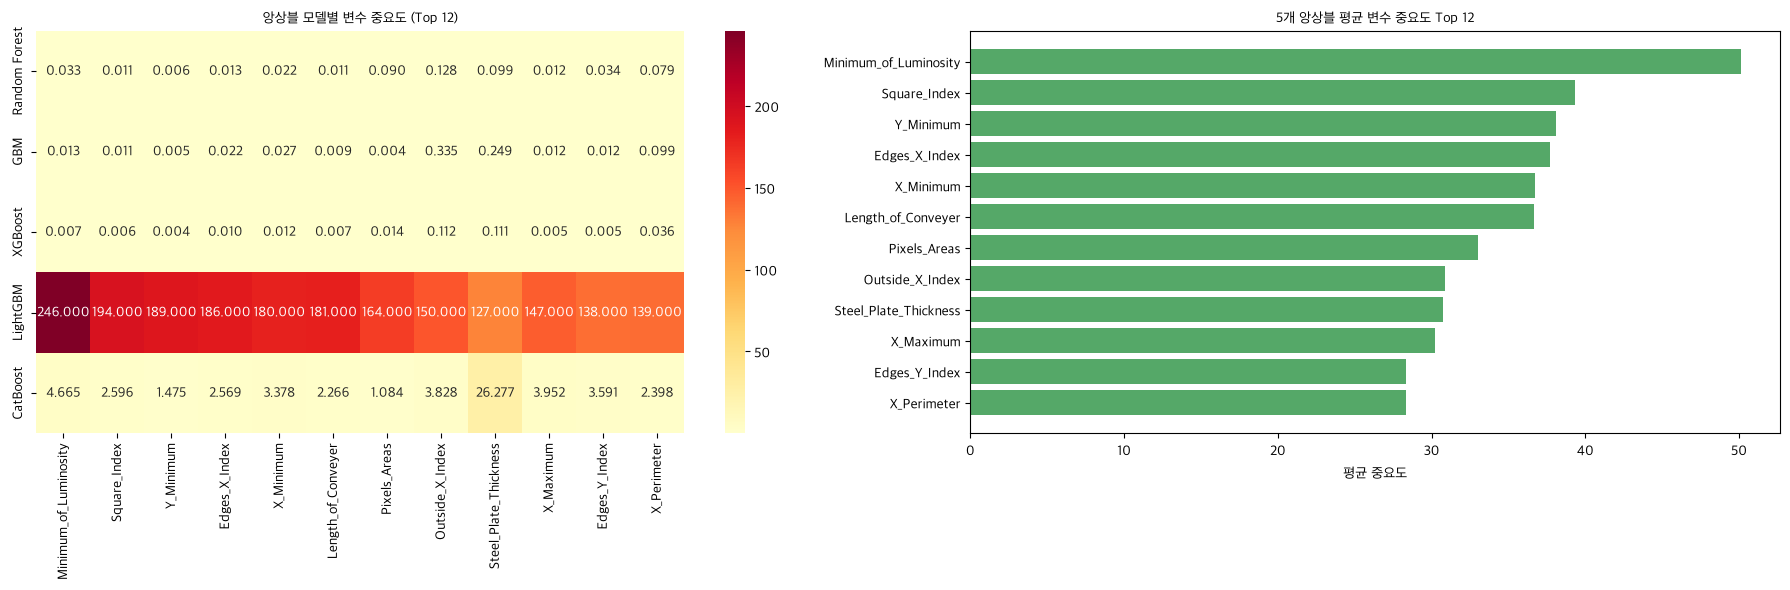

공통 핵심 변수 (5개 모델 모두 Top 15 안에 포함):
  - Luminosity_Index
  - Minimum_of_Luminosity
  - Outside_X_Index
  - Steel_Plate_Thickness
  - X_Minimum


In [63]:
# 불균형 완화 적용 5개 앙상블 — 변수 중요도 비교
cls_importance = pd.DataFrame({
    name: model.feature_importances_
    for name, model in cls_models_balanced.items()
}, index=X_train_cls.columns)

top_cls_features = cls_importance.mean(axis=1).sort_values(ascending=False).head(12).index

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(cls_importance.loc[top_cls_features].T, annot=True, fmt=".3f",
            cmap="YlOrRd", ax=axes[0])
set_kr_title(axes[0], "앙상블 모델별 변수 중요도 (Top 12)")

# 평균 중요도 막대그래프
mean_imp = cls_importance.mean(axis=1).sort_values(ascending=False).head(12)
axes[1].barh(mean_imp.index[::-1], mean_imp.values[::-1], color="#55A868")
set_kr_title(axes[1], "5개 앙상블 평균 변수 중요도 Top 12")
axes[1].set_xlabel("평균 중요도")
plt.tight_layout()
plt.show()

print("공통 핵심 변수 (5개 모델 모두 Top 15 안에 포함):")
top15_sets = [set(cls_importance[name].sort_values(ascending=False).head(15).index) for name in cls_importance.columns]
common_cls = sorted(set.intersection(*top15_sets))
for f in common_cls:
    print(f"  - {f}")

**[과제]** 써니는 불균형 완화 이후 F1-score가 가장 좋았던 모델의 성능을 하이퍼파라미터 튜닝으로 더 끌어올리고 싶습니다. AI와 함께 적절한 탐색 범위를 설정하여 GridSearchCV로 성능을 개선해 보세요.

'XGBoost' 추가 GridSearchCV 진행...

최적 파라미터: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
CV F1: 0.9741

[튜닝 전]
[XGBoost]
  Accuracy  : 0.9794
  Precision : 0.9646
  Recall    : 0.9316
  F1-score  : 0.9478
  혼동행렬:
[[462   4]
 [  8 109]]
[튜닝 후]
[XGBoost (fine-tuned)]
  Accuracy  : 0.9811
  Precision : 0.9649
  Recall    : 0.9402
  F1-score  : 0.9524
  ROC-AUC   : 0.9941
  혼동행렬:
[[462   4]
 [  7 110]]


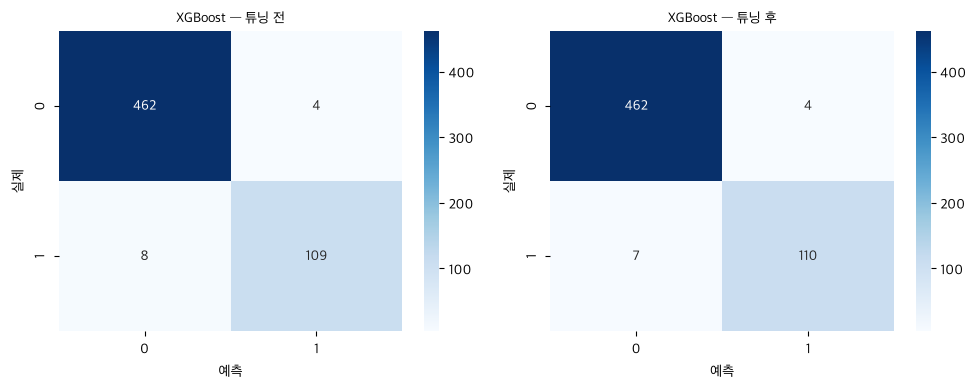

In [64]:
# 최고 F1 모델 추가 하이퍼파라미터 튜닝
best_cls_base = cls_models_balanced[best_cls_name]
print(f"'{best_cls_name}' 추가 GridSearchCV 진행...\n")

if best_cls_name == "Random Forest":
    fine_cls_est = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
    fine_cls_grid = {
        "n_estimators": [200, 400, 600],
        "max_depth": [8, 12, 16, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.5, 0.8],
    }
    fine_cls_search = GridSearchCV(fine_cls_est, fine_cls_grid, scoring="f1", cv=3, n_jobs=-1)
    fine_cls_search.fit(X_train_cls, Y_train_cls)
    tuned_cls = fine_cls_search.best_estimator_

elif best_cls_name == "XGBoost":
    fine_cls_est = XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight,
                                 eval_metric="logloss", verbosity=0)
    fine_cls_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.08],
        "max_depth": [4, 5, 6],
        "subsample": [0.8, 0.9],
        "colsample_bytree": [0.7, 0.9],
    }
    fine_cls_search = GridSearchCV(fine_cls_est, fine_cls_grid, scoring="f1", cv=3, n_jobs=-1)
    fine_cls_search.fit(X_train_cls, Y_train_cls)
    tuned_cls = fine_cls_search.best_estimator_

elif best_cls_name == "LightGBM":
    fine_cls_est = LGBMClassifier(random_state=RANDOM_STATE, is_unbalance=True, verbose=-1)
    fine_cls_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.08],
        "max_depth": [4, 5, 6],
        "num_leaves": [15, 31, 63],
    }
    fine_cls_search = GridSearchCV(fine_cls_est, fine_cls_grid, scoring="f1", cv=3, n_jobs=-1)
    fine_cls_search.fit(X_train_cls, Y_train_cls)
    tuned_cls = fine_cls_search.best_estimator_

elif best_cls_name == "CatBoost":
    fine_cls_est = CatBoostClassifier(random_state=RANDOM_STATE, auto_class_weights="Balanced", verbose=0)
    fine_cls_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.08],
        "max_depth": [4, 5, 6],
        "l2_leaf_reg": [1, 3, 5, 7],
    }
    fine_cls_search = GridSearchCV(fine_cls_est, fine_cls_grid, scoring="f1", cv=3, n_jobs=-1)
    fine_cls_search.fit(X_train_cls, Y_train_cls)
    tuned_cls = fine_cls_search.best_estimator_

else:  # GBM
    fine_cls_grid = {
        "n_estimators": [200, 400],
        "learning_rate": [0.03, 0.05, 0.08],
        "max_depth": [4, 5, 6],
        "min_samples_leaf": [1, 3, 5],
    }
    fine_cls_search = GridSearchCV(
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        fine_cls_grid, scoring="f1", cv=3, n_jobs=-1,
    )
    fine_cls_search.fit(X_train_cls, Y_train_cls, sample_weight=sample_weights)
    tuned_cls = fine_cls_search.best_estimator_

print("최적 파라미터:", fine_cls_search.best_params_)
print(f"CV F1: {fine_cls_search.best_score_:.4f}")

pred_before = best_cls_base.predict(X_test_cls)
pred_after = tuned_cls.predict(X_test_cls)
proba_after = tuned_cls.predict_proba(X_test_cls)[:, 1]

print("\n[튜닝 전]")
get_classscore(Y_test_cls, pred_before, label=best_cls_name)
print("[튜닝 후]")
final_cls_metrics = get_classscore(Y_test_cls, pred_after, proba_after, f"{best_cls_name} (fine-tuned)")

# 최종 혼동행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, title in zip(axes, [pred_before, pred_after], ["튜닝 전", "튜닝 후"]):
    cm = confusion_matrix(Y_test_cls, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["0", "1"], yticklabels=["0", "1"])
    set_kr_title(ax, f"{best_cls_name} — {title}")
    ax.set_xlabel("예측")
    ax.set_ylabel("실제")
plt.tight_layout()
plt.show()